In [ ]:
#1 Run this cell first if xarray is not installed
!pip install xarray netcdf4 scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import warnings
warnings.filterwarnings('ignore')

print('✓ All libraries loaded')

✓ All libraries loaded


In [ ]:
#3 ── UPDATE THIS PATH to wherever you saved the file ──
EMDAT_PATH  = 'emdat_floods.xlsx'
WB_PATH     = 'world_bank.csv'
ONI_PATH    = 'oni_data.txt'
ERA5_PATH   = 'era5_precip.nc'
OUTPUT_PATH = 'flood_severity_final.csv'

**Datasets**

**EM-DAT**

In [ ]:
#6 Load EM-DAT
emdat = pd.read_excel(EMDAT_PATH)
print(f'Loaded EM-DAT: {emdat.shape[0]} rows, {emdat.shape[1]} columns')

# ── Keep only the columns we need ──
keep_cols = [
    'DisNo.', 'ISO', 'Country', 'Region', 'Subregion',
    'Disaster Subtype', 'Origin', 'Associated Types',
    'Start Year', 'Start Month', 'Start Day',
    'End Year',   'End Month',   'End Day',
    'River Basin', 'Latitude', 'Longitude',
    # outcome cols — used ONLY to create the severity label, then dropped
    'Total Deaths', 'No. Injured', 'No. Affected',
    'No. Homeless', 'Total Affected',
    "Total Damage ('000 US$)"
]
emdat = emdat[keep_cols].copy()

# ── Basic cleaning ──
emdat['Start Month'] = emdat['Start Month'].fillna(1).astype(int)
emdat['Start Year']  = emdat['Start Year'].astype(int)

# Engineer: flood duration in days
def safe_date(row, prefix):
    try:
        y = int(row[f'{prefix} Year'])
        m = int(row[f'{prefix} Month']) if not pd.isna(row[f'{prefix} Month']) else 1
        d = int(row[f'{prefix} Day'])   if not pd.isna(row[f'{prefix} Day'])   else 1
        return pd.Timestamp(year=y, month=m, day=d)
    except:
        return pd.NaT

emdat['start_date'] = emdat.apply(lambda r: safe_date(r, 'Start'), axis=1)
emdat['end_date']   = emdat.apply(lambda r: safe_date(r, 'End'),   axis=1)
emdat['duration_days'] = (emdat['end_date'] - emdat['start_date']).dt.days.clip(lower=0).fillna(0).astype(int)

# Engineer: has associated hazard (landslide etc.)
emdat['has_associated_hazard'] = emdat['Associated Types'].notna().astype(int)

# Clean Origin into grouped categories
def group_origin(val):
    if pd.isna(val): return 'Unknown'
    v = str(val).lower()
    if 'monsoon' in v: return 'Monsoon'
    if 'heavy rain' in v or 'torrential' in v: return 'Heavy Rain'
    if 'snow' in v or 'melt' in v: return 'Snowmelt'
    if 'tropical' in v or 'cyclone' in v or 'storm' in v: return 'Tropical Storm'
    if 'dam' in v or 'dike' in v: return 'Dam/Dike Failure'
    return 'Other'

emdat['origin_group'] = emdat['Origin'].apply(group_origin)

print(f'After cleaning: {emdat.shape}')
print(f'\nFlood subtypes:\n{emdat["Disaster Subtype"].value_counts()}')
print(f'\nOrigin groups:\n{emdat["origin_group"].value_counts()}')

Loaded EM-DAT: 922 rows, 47 columns
After cleaning: (922, 28)

Flood subtypes:
Disaster Subtype
Flood (General)    376
Riverine flood     369
Flash flood        170
Coastal flood        7
Name: count, dtype: int64

Origin groups:
origin_group
Unknown             355
Heavy Rain          298
Monsoon             221
Other                30
Snowmelt              9
Tropical Storm        8
Dam/Dike Failure      1
Name: count, dtype: int64


**World Bank**

In [ ]:
#8 Load World Bank CSV
wb_raw = pd.read_csv(WB_PATH)

# Drop footer rows (World Bank adds 2 junk rows at the bottom)
wb_raw = wb_raw[wb_raw['Country Code'].notna()]
wb_raw = wb_raw[wb_raw['Country Code'].str.len() == 3]

# The 5 indicators we want
indicators = {
    'NY.GDP.PCAP.CD' : 'gdp_per_capita',
    'EN.POP.DNST'    : 'pop_density',
    'SP.URB.TOTL.IN.ZS': 'urban_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_exp_pct',
    'NV.AGR.TOTL.ZS' : 'agri_pct'
}

# Filter to just our indicators
wb_filtered = wb_raw[wb_raw['Series Code'].isin(indicators.keys())].copy()
print(f'WB rows after filter: {len(wb_filtered)} (= 9 countries × 5 indicators = {9*5})')

# Identify year columns  (format: '1990 [YR1990]')
year_cols = [c for c in wb_raw.columns if '[YR' in str(c)]

# Melt from wide → long
wb_long = wb_filtered.melt(
    id_vars=['Country Code', 'Series Code'],
    value_vars=year_cols,
    var_name='year_label',
    value_name='value'
)

# Extract year number from '1990 [YR1990]'
wb_long['Year'] = wb_long['year_label'].str.extract(r'(\d{4})').astype(int)

# Replace '..' (World Bank missing) with NaN
wb_long['value'] = pd.to_numeric(wb_long['value'].replace('..', np.nan), errors='coerce')

# Rename Series Code → friendly name
wb_long['indicator'] = wb_long['Series Code'].map(indicators)

# Pivot back to wide: one column per indicator
wb_wide = wb_long.pivot_table(
    index=['Country Code', 'Year'],
    columns='indicator',
    values='value'
).reset_index()
wb_wide.columns.name = None

print(f'\nWB reshaped: {wb_wide.shape}')
print(wb_wide.head(3).to_string())

WB rows after filter: 45 (= 9 countries × 5 indicators = 45)

WB reshaped: (315, 7)
  Country Code  Year  agri_pct  gdp_per_capita  health_exp_pct  pop_density  urban_pct
0          AFG  1990       NaN             NaN             NaN    18.468424  17.264035
1          AFG  1991       NaN             NaN             NaN    18.764667  17.376660
2          AFG  1992       NaN             NaN             NaN    20.359343  17.488203


In [ ]:
#9 Merge WB onto EM-DAT on ISO + Start Year
df = emdat.merge(
    wb_wide,
    left_on  = ['ISO', 'Start Year'],
    right_on = ['Country Code', 'Year'],
    how='left'
).drop(columns=['Country Code', 'Year'])

print(f'After WB merge: {df.shape}')
wb_cols = list(indicators.values())
print(f'\nWB feature coverage (% non-null):')
for c in wb_cols:
    pct = df[c].notna().sum() / len(df) * 100
    print(f'  {c}: {pct:.1f}%')

After WB merge: (922, 33)

WB feature coverage (% non-null):
  gdp_per_capita: 75.4%
  pop_density: 74.6%
  urban_pct: 77.2%
  health_exp_pct: 58.2%
  agri_pct: 75.4%


**ONI text file**

In [ ]:
#11 Parse ONI text file
# Format: YEAR  JAN  FEB  MAR  APR  MAY  JUN  JUL  AUG  SEP  OCT  NOV  DEC
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

oni_rows = []
with open(ONI_PATH, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 13:
            try:
                year = int(parts[0])
                vals = [float(x) for x in parts[1:]]
                for month_idx, val in enumerate(vals, start=1):
                    oni_rows.append({
                        'Year': year,
                        'Month': month_idx,
                        'oni_value': val
                    })
            except ValueError:
                pass  # skip header/footer lines

oni = pd.DataFrame(oni_rows)

# Replace -99.9 (missing) with NaN
oni['oni_value'] = oni['oni_value'].replace(-99.9, np.nan)

# Create ENSO phase label
def enso_phase(val):
    if pd.isna(val):    return 'Unknown'
    if val >= 0.5:      return 'El Nino'
    if val <= -0.5:     return 'La Nina'
    return 'Neutral'

oni['enso_phase'] = oni['oni_value'].apply(enso_phase)

print(f'ONI table: {oni.shape}')
print(f'Year range: {oni.Year.min()} – {oni.Year.max()}')
print(f'\nENSO phase distribution:\n{oni["enso_phase"].value_counts()}')
print(f'\nSample:')
print(oni[oni['Year']==2010].head(6).to_string(index=False))

ONI table: (924, 4)
Year range: 1950 – 2026

ENSO phase distribution:
enso_phase
Neutral    418
La Nina    252
El Nino    245
Unknown      9
Name: count, dtype: int64

Sample:
 Year  Month  oni_value enso_phase
 2010      1       1.50    El Nino
 2010      2       1.22    El Nino
 2010      3       0.84    El Nino
 2010      4       0.35    Neutral
 2010      5      -0.17    Neutral
 2010      6      -0.66    La Nina


In [ ]:
#12 Merge ONI onto main df on Start Year + Start Month
df = df.merge(
    oni,
    left_on  = ['Start Year', 'Start Month'],
    right_on = ['Year', 'Month'],
    how='left'
).drop(columns=['Year', 'Month'])

coverage = df['oni_value'].notna().sum() / len(df) * 100
print(f'After ONI merge: {df.shape}')
print(f'ONI coverage: {coverage:.1f}%')
print(f'\nENSO phase in flood events:\n{df["enso_phase"].value_counts()}')

After ONI merge: (922, 35)
ONI coverage: 99.7%

ENSO phase in flood events:
enso_phase
Neutral    501
El Nino    214
La Nina    204
Unknown      1
Name: count, dtype: int64


**ERA5**

In [ ]:
#14 Country bounding boxes: (North, South, West, East)
COUNTRY_BOXES = {
    'AFG': (38, 29, 60, 75),
    'BGD': (26, 21, 88, 92),
    'BTN': (28, 27, 89, 92),
    'IND': (37,  8, 68, 97),
    'IRN': (40, 25, 44, 64),
    'LKA': (10,  6, 80, 82),
    'MDV': ( 8, -5, 72, 74),
    'NPL': (30, 26, 80, 88),
    'PAK': (37, 24, 60, 77),
}

print('Loading ERA5 NetCDF file (may take 10–30 seconds)...')
ds = xr.open_dataset(ERA5_PATH)

# ERA5 variable is 'tp' (total precipitation) in metres
# Time coordinate is 'valid_time'
times = pd.to_datetime(ds['valid_time'].values)
print(f'ERA5 loaded: {len(times)} months ({str(times[0])[:7]} → {str(times[-1])[:7]})')

# Extract mean precipitation per country per month → build lookup table
print('Extracting country-level precipitation...')

era5_rows = []
for iso, (n, s, w, e) in COUNTRY_BOXES.items():
    # Slice the grid to the country bounding box
    sub = ds['tp'].sel(
        latitude  = slice(n, s),   # ERA5 lat is stored N→S (decreasing)
        longitude = slice(w, e)
    )
    # Mean over spatial grid → one value per timestep
    country_mean = sub.mean(dim=['latitude','longitude']).values
    # Convert metres → millimetres
    country_mm = country_mean * 1000

    for t_idx, t in enumerate(times):
        era5_rows.append({
            'ISO'   : iso,
            'Year'  : t.year,
            'Month' : t.month,
            'precip_mm': round(country_mm[t_idx], 4)
        })
    print(f'  ✓ {iso}')

era5_df = pd.DataFrame(era5_rows)
print(f'\nERA5 table built: {era5_df.shape}')
print(era5_df[era5_df['ISO']=='IND'].head(3).to_string(index=False))

Loading ERA5 NetCDF file (may take 10–30 seconds)...
ERA5 loaded: 528 months (1981-01 → 2024-12)
Extracting country-level precipitation...
  ✓ AFG
  ✓ BGD
  ✓ BTN
  ✓ IND
  ✓ IRN
  ✓ LKA
  ✓ MDV
  ✓ NPL
  ✓ PAK

ERA5 table built: (4752, 4)
ISO  Year  Month  precip_mm
IND  1981      1     0.7946
IND  1981      2     0.7413
IND  1981      3     1.0972


In [ ]:
#15 Compute precipitation anomaly:
# For each country+month, calculate the long-term mean (climatology)
# anomaly = actual - climatology  (positive = wetter than normal)
clim = (
    era5_df.groupby(['ISO','Month'])['precip_mm']
    .mean()
    .reset_index()
    .rename(columns={'precip_mm': 'precip_climatology'})
)
era5_df = era5_df.merge(clim, on=['ISO','Month'], how='left')
era5_df['precip_anomaly_mm'] = era5_df['precip_mm'] - era5_df['precip_climatology']

print('Precipitation anomaly computed.')
print(era5_df[era5_df['ISO']=='IND'].head(3)[['ISO','Year','Month','precip_mm','precip_climatology','precip_anomaly_mm']].to_string(index=False))

Precipitation anomaly computed.
ISO  Year  Month  precip_mm  precip_climatology  precip_anomaly_mm
IND  1981      1     0.7946            0.771534           0.023066
IND  1981      2     0.7413            0.819470          -0.078170
IND  1981      3     1.0972            0.979907           0.117293


In [ ]:
#16 Merge ERA5 onto main df on ISO + Start Year + Start Month
df = df.merge(
    era5_df[['ISO','Year','Month','precip_mm','precip_anomaly_mm']],
    left_on  = ['ISO', 'Start Year', 'Start Month'],
    right_on = ['ISO', 'Year', 'Month'],
    how='left'
).drop(columns=['Year','Month'])

cov = df['precip_mm'].notna().sum() / len(df) * 100
print(f'After ERA5 merge: {df.shape}')
print(f'Precipitation coverage: {cov:.1f}% (pre-1981 events will be NaN — expected)')

After ERA5 merge: (922, 37)
Precipitation coverage: 86.1% (pre-1981 events will be NaN — expected)


**TARGET VARIABLE: SEVERITY**

In [ ]:
#18 ── IMPORTANT: severity label is created from outcome columns,
# which are then DROPPED from features to prevent data leakage ──

# Only rows with both Deaths AND Total Affected can get a label
has_label = df['Total Deaths'].notna() & df['Total Affected'].notna()
print(f'Rows with both Deaths + Affected: {has_label.sum()} / {len(df)}')

# Composite severity score (log-transform reduces skew from extreme events)
df['severity_score'] = (
    0.6 * np.log1p(df['Total Deaths'].fillna(0)) +
    0.4 * np.log1p(df['Total Affected'].fillna(0))
)

# Tertile binning → balanced Low / Medium / High classes
df_labeled = df[has_label].copy()
df_labeled['severity'] = pd.qcut(
    df_labeled['severity_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print(f'\nSeverity distribution:')
print(df_labeled['severity'].value_counts())

# Show what each tier means in real terms
print(f'\nMedian Deaths per tier:')
print(df_labeled.groupby('severity')['Total Deaths'].median())
print(f'\nMedian Total Affected per tier:')
print(df_labeled.groupby('severity')['Total Affected'].median())

Rows with both Deaths + Affected: 646 / 922

Severity distribution:
severity
Low       216
High      216
Medium    214
Name: count, dtype: int64

Median Deaths per tier:
severity
Low        16.0
Medium     37.0
High      212.0
Name: Total Deaths, dtype: float64

Median Total Affected per tier:
severity
Low          1503.0
Medium      60333.0
High      1893000.0
Name: Total Affected, dtype: float64


In [ ]:
#19 ── Drop ALL outcome/leakage columns ──
# These were used to create the label — they must NOT be features
leakage_cols = [
    'Total Deaths', 'No. Injured', 'No. Affected',
    'No. Homeless', 'Total Affected',
    "Total Damage ('000 US$)",
    'severity_score',
    # also drop raw date cols no longer needed
    'start_date', 'end_date',
    'Start Day', 'End Year', 'End Month', 'End Day'
]
df_labeled = df_labeled.drop(columns=leakage_cols, errors='ignore')

print(f'Dataset shape after dropping leakage cols: {df_labeled.shape}')
print(f'\nFinal columns:')
print(list(df_labeled.columns))

Dataset shape after dropping leakage cols: (646, 26)

Final columns:
['DisNo.', 'ISO', 'Country', 'Region', 'Subregion', 'Disaster Subtype', 'Origin', 'Associated Types', 'Start Year', 'Start Month', 'River Basin', 'Latitude', 'Longitude', 'duration_days', 'has_associated_hazard', 'origin_group', 'agri_pct', 'gdp_per_capita', 'health_exp_pct', 'pop_density', 'urban_pct', 'oni_value', 'enso_phase', 'precip_mm', 'precip_anomaly_mm', 'severity']


In [ ]:
#20 ── Select only the features that go into the model ──
feature_cols = [
    'Start Year',
    'Disaster Subtype',
    'origin_group',
    'ISO',
    'Start Month',
    'duration_days',
    'has_associated_hazard',
    'gdp_per_capita',
    'pop_density',
    'urban_pct',
    'agri_pct',
    'health_exp_pct',
    'oni_value',
    'enso_phase',
    'precip_mm',
    'precip_anomaly_mm',
]

# Use .copy() with reset_index to avoid SettingWithCopyWarning
df_model = df_labeled[feature_cols + ['severity']].copy().reset_index(drop=True)
print(f'Model dataset before cleaning: {df_model.shape}')
print(f'Nulls before cleaning:\n{df_model.isnull().sum()[df_model.isnull().sum() > 0]}')

# Fill categorical NaNs
cat_cols = ['Disaster Subtype', 'origin_group', 'enso_phase']
for c in cat_cols:
    df_model[c] = df_model[c].fillna('Unknown')

# Fill numeric NaNs with median — using loc to avoid silent failure
num_cols = ['gdp_per_capita', 'pop_density', 'urban_pct', 'agri_pct',
            'health_exp_pct', 'oni_value', 'precip_mm', 'precip_anomaly_mm']
for c in num_cols:
    median_val = df_model[c].median()
    df_model.loc[df_model[c].isna(), c] = median_val
    print(f'  {c}: filled with median = {median_val:.3f}')

# Verify
remaining = df_model.isnull().sum().sum()
print(f'\nNulls remaining after cleaning: {remaining}')

# If still nulls, drop those rows — they can't be used
if remaining > 0:
    print(f'Dropping {remaining} unfillable rows...')
    df_model = df_model.dropna().reset_index(drop=True)

print(f'\nFinal model dataset: {df_model.shape}')
print(f'Class distribution:\n{df_model["severity"].value_counts()}')

Model dataset before cleaning: (646, 17)
Nulls before cleaning:
gdp_per_capita       127
pop_density          134
urban_pct            114
agri_pct             127
health_exp_pct       245
oni_value              2
enso_phase             1
precip_mm             64
precip_anomaly_mm     64
dtype: int64
  gdp_per_capita: filled with median = 992.520
  pop_density: filled with median = 325.665
  urban_pct: filled with median = 29.781
  agri_pct: filled with median = 19.535
  health_exp_pct: filled with median = 3.669
  oni_value: filled with median = -0.070
  precip_mm: filled with median = 5.142
  precip_anomaly_mm: filled with median = 0.324

Nulls remaining after cleaning: 0

Final model dataset: (646, 17)
Class distribution:
severity
Low       216
High      216
Medium    214
Name: count, dtype: int64


In [ ]:
df_model.to_csv('flood_severity_clean.csv', index=False)
print(f'Saved: flood_severity_clean.csv → {df_model.shape}')
print(f'\nClass distribution:\n{df_model["severity"].value_counts()}')

Saved: flood_severity_clean.csv → (646, 17)

Class distribution:
severity
Low       216
High      216
Medium    214
Name: count, dtype: int64


In [ ]:
#23 Show a few sample rows to verify everything looks right
print('Sample rows from final dataset:')
df_model.sample(5, random_state=42)[[
    'ISO','Start Month','Disaster Subtype',
    'gdp_per_capita','pop_density','oni_value',
    'enso_phase','precip_mm','severity'
]].to_string(index=False)

Sample rows from final dataset:


'ISO  Start Month Disaster Subtype  gdp_per_capita  pop_density  oni_value enso_phase  precip_mm severity\nBGD            7   Riverine flood     1649.283809  1235.399339      -0.31    Neutral  16.327499     High\nNPL            8   Riverine flood      185.794600   136.535476       0.38    Neutral  10.259900      Low\nPAK            6  Flood (General)     1538.322813   316.133078      -0.78    La Nina   1.024800     High\nPAK            7      Flash flood      987.304571   258.456630      -1.05    La Nina   3.332900     High\nIND            6   Riverine flood     1553.883961   441.370108       0.23    Neutral   5.179000   Medium'

In [ ]:
#24 Severity by country — useful insight for your report
print('High severity rate by country:')
ct = pd.crosstab(df_model['ISO'], df_model['severity'], normalize='index').round(3)
print(ct.sort_values('High', ascending=False))

print('\nHigh severity rate by ENSO phase:')
ct2 = pd.crosstab(df_model['enso_phase'], df_model['severity'], normalize='index').round(3)
print(ct2)

print('\nMean precipitation by severity tier:')
print(df_model.groupby('severity')['precip_mm'].mean().round(2))

High severity rate by country:
severity    Low  Medium   High
ISO                           
IND       0.234   0.238  0.528
BGD       0.104   0.455  0.442
PAK       0.430   0.267  0.302
NPL       0.298   0.404  0.298
LKA       0.309   0.574  0.118
AFG       0.519   0.377  0.104
IRN       0.707   0.224  0.069
BTN       0.500   0.500  0.000

High severity rate by ENSO phase:
severity      Low  Medium   High
enso_phase                      
El Nino     0.391   0.368  0.241
La Nina     0.288   0.349  0.363
Neutral     0.332   0.310  0.359
Unknown     0.500   0.500  0.000

Mean precipitation by severity tier:
severity
Low       3.74
Medium    6.31
High      7.49
Name: precip_mm, dtype: float32


##EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('flood_severity_clean.csv')
print(df.shape)
df.head()

(646, 17)


,Start Year,Disaster Subtype,origin_group,ISO,Start Month,duration_days,has_associated_hazard,gdp_per_capita,pop_density,urban_pct,agri_pct,health_exp_pct,oni_value,enso_phase,precip_mm,precip_anomaly_mm,severity
0,2026,Flood (General),Other,AFG,4,7,1,992.519585,325.665412,29.781043,19.534543,3.669015,-0.07,Unknown,5.1424,0.324407,Medium
1,1987,Riverine flood,Unknown,IND,8,0,1,992.519585,325.665412,29.781043,19.534543,3.669015,1.70,El Nino,7.6218,0.152800,High
2,1988,Riverine flood,Unknown,IND,6,0,0,992.519585,325.665412,29.781043,19.534543,3.669015,-1.30,La Nina,6.6355,-0.209895,High
3,1995,Riverine flood,Monsoon,PAK,7,22,0,450.550279,174.582624,31.914461,23.421879,3.669015,-0.24,Neutral,4.0214,1.651314,High
4,1989,Riverine flood,Heavy Rain,PAK,8,0,0,992.519585,325.665412,29.781043,19.534543,3.669015,-0.27,Neutral,1.8431,-0.308557,Medium


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646 entries, 0 to 645
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Start Year             646 non-null    int64  
 1   Disaster Subtype       646 non-null    object 
 2   origin_group           646 non-null    object 
 3   ISO                    646 non-null    object 
 4   Start Month            646 non-null    int64  
 5   duration_days          646 non-null    int64  
 6   has_associated_hazard  646 non-null    int64  
 7   gdp_per_capita         646 non-null    float64
 8   pop_density            646 non-null    float64
 9   urban_pct              646 non-null    float64
 10  agri_pct               646 non-null    float64
 11  health_exp_pct         646 non-null    float64
 12  oni_value              646 non-null    float64
 13  enso_phase             646 non-null    object 
 14  precip_mm              646 non-null    float64
 15  precip

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)
print(f'\n% missing:\n{(missing/len(df)*100).round(1)}')

Series([], dtype: int64)

% missing:
Series([], dtype: float64)


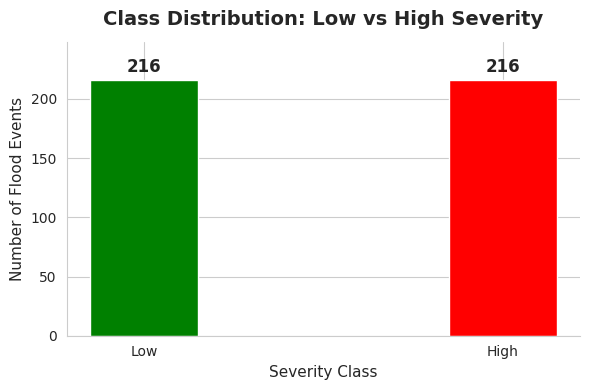

In [ ]:
df_bin = df[df['severity'] != 'Medium'].copy().reset_index(drop=True)
df_bin['severity_bin'] = (df_bin['severity'] == 'High').astype(int)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(['Low', 'High'],
              [df_bin['severity'].value_counts()['Low'],
               df_bin['severity'].value_counts()['High']],
              color=['green','red'], width=0.3, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution: Low vs High Severity', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Flood Events', fontsize=11)
ax.set_xlabel('Severity Class', fontsize=11)
ax.set_ylim(0, df_bin['severity'].value_counts().max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

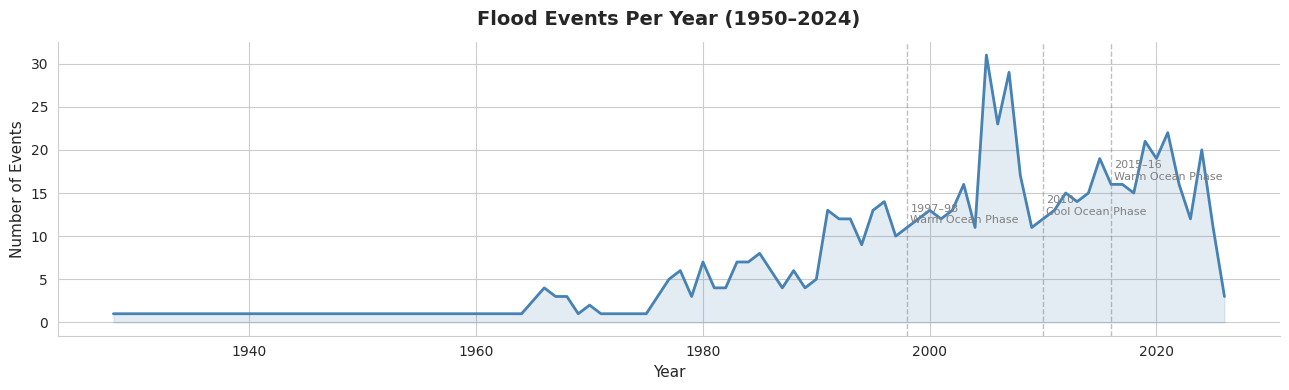

In [ ]:
yearly = df.groupby('Start Year').size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(13,4))
ax.fill_between(yearly['Start Year'], yearly['count'], alpha=0.15, color='steelblue')
ax.plot(yearly['Start Year'], yearly['count'], color='steelblue', linewidth=2)
ax.set_title('Flood Events Per Year (1962–2022)', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Number of Events', fontsize=11)
ax.set_xlabel('Year', fontsize=11)
# highlight notable ENSO years
for yr, label in [(1998,'1997–98\nWarm Ocean Phase'), (2010,'2010\nCool Ocean Phase'), (2016,'2015–16\nWarm Ocean Phase')]:
    if yr in yearly['Start Year'].values:
        val = yearly[yearly['Start Year']==yr]['count'].values[0]
        ax.axvline(yr, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(yr+0.3, val+0.5, label, fontsize=8, color='gray')
sns.despine()
plt.tight_layout()
plt.show()

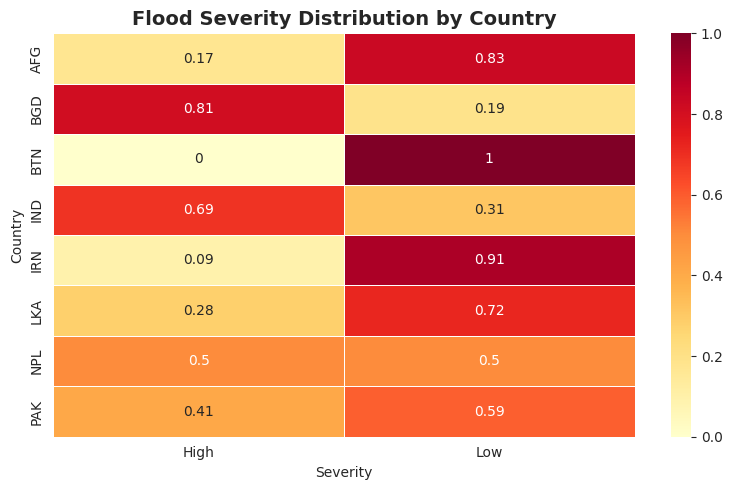

In [ ]:
ct = pd.crosstab(
    df_bin['ISO'],
    df_bin['severity'],
    normalize='index'
).round(2)

plt.figure(figsize=(8,5))

sns.heatmap(
    ct,
    annot=True,
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title('Flood Severity Distribution by Country', fontsize=14, weight='bold')
plt.xlabel('Severity')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

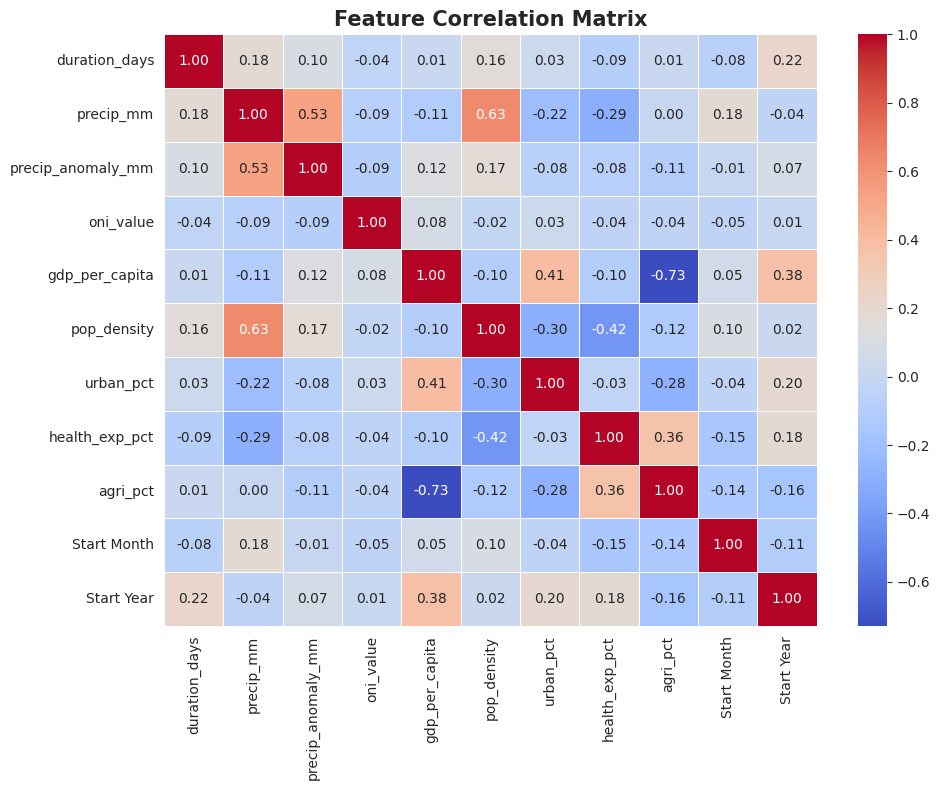

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
num_cols = [
    'duration_days',
    'precip_mm',
    'precip_anomaly_mm',
    'oni_value',
    'gdp_per_capita',
    'pop_density',
    'urban_pct',
    'health_exp_pct',
    'agri_pct',
    'Start Month',
    'Start Year'
]

# Compute correlation matrix
corr = df[num_cols].corr()

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Feature Correlation Matrix', fontsize=15, weight='bold')

plt.tight_layout()
plt.show()

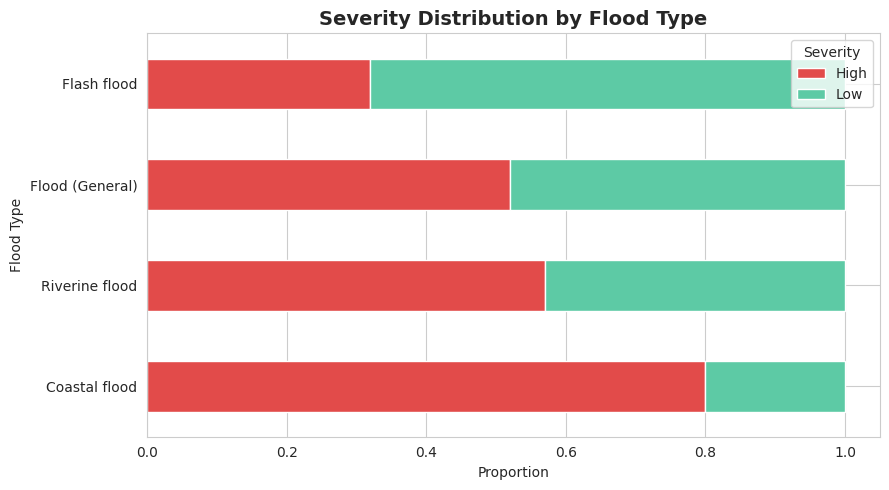

In [ ]:
ct2 = pd.crosstab(
    df_bin['Disaster Subtype'],
    df_bin['severity'],
    normalize='index'
).round(2)

ct2 = ct2.sort_values('High', ascending=False)

ct2.plot(
    kind='barh',
    stacked=True,
    figsize=(9,5),
    color=['#E24B4A', '#5DCAA5']
)

plt.title('Severity Distribution by Flood Type', fontsize=14, weight='bold')
plt.xlabel('Proportion')
plt.ylabel('Flood Type')

plt.legend(title='Severity')

plt.tight_layout()
plt.show()

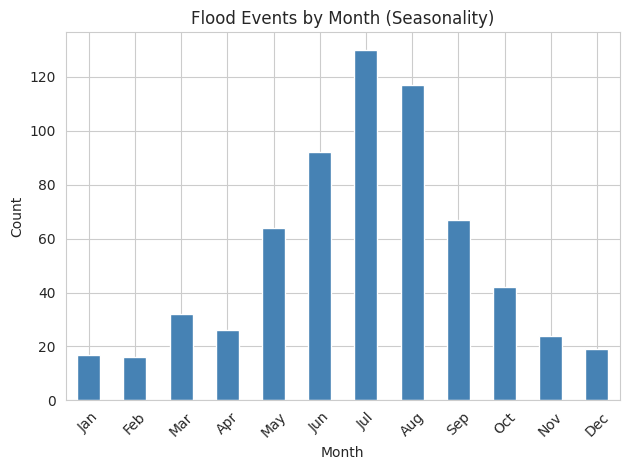

In [ ]:
df.groupby('Start Month').size().plot(kind='bar', color='steelblue')
plt.title('Flood Events by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.show()

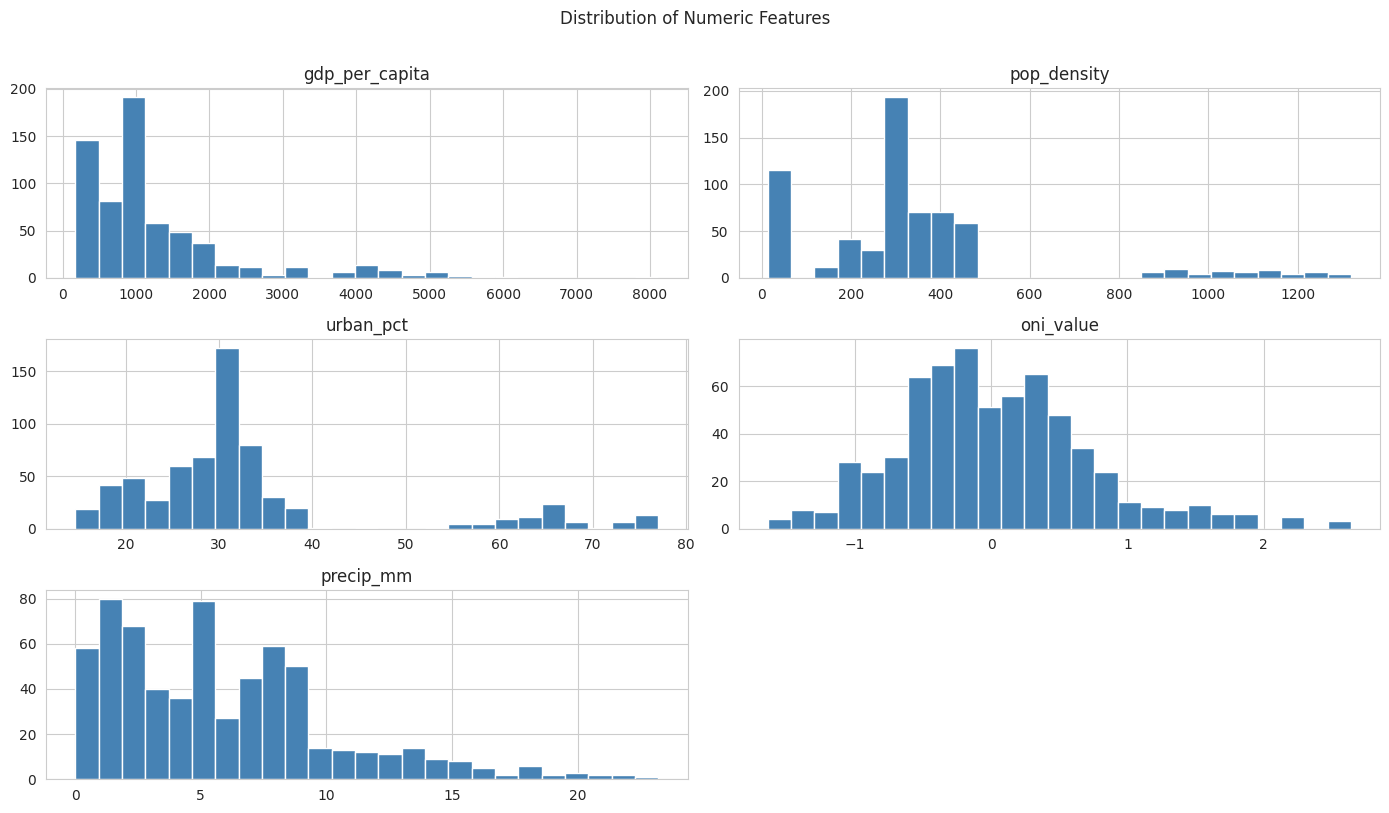

In [ ]:
num_cols = ['gdp_per_capita','pop_density','urban_pct','oni_value','precip_mm']
df[num_cols].hist(bins=25, figsize=(14,8), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Numeric Features', y=1.01)
plt.tight_layout()
plt.show()

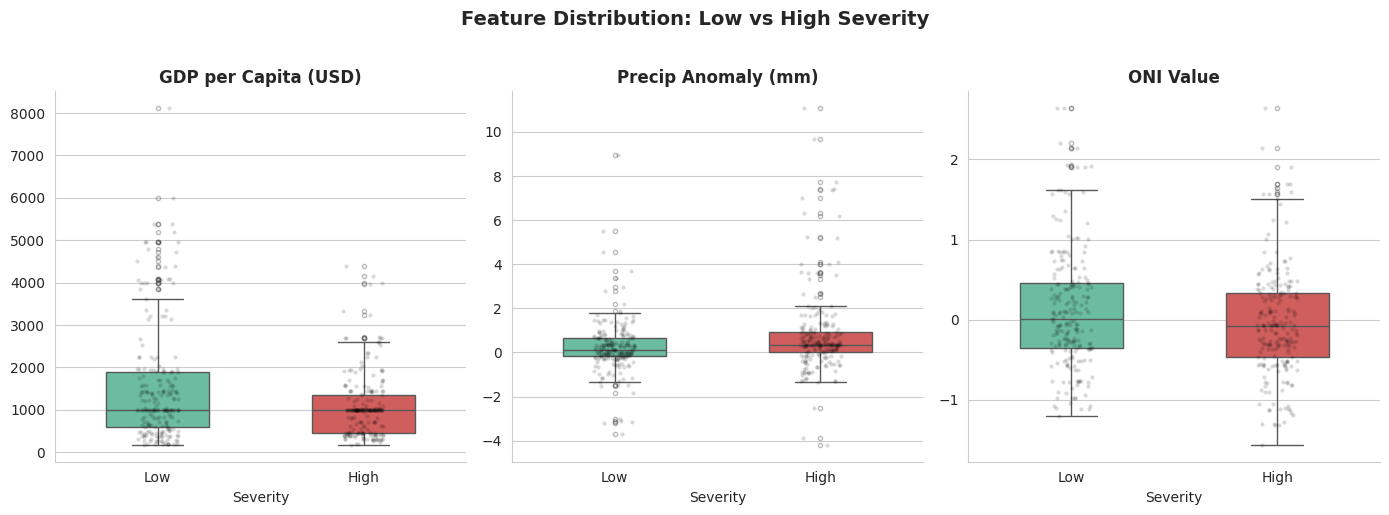

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14,5))
pairs = [
    ('gdp_per_capita',    'GDP per Capita (USD)'),
    ('precip_anomaly_mm', 'Precip Anomaly (mm)'),
    ('oni_value',         'ONI Value'),
]
for ax, (col, label) in zip(axes, pairs):
    sns.boxplot(data=df_bin, x='severity', y=col,
                palette=['#5DCAA5','#E24B4A'],
                order=['Low','High'], width=0.5,
                flierprops=dict(marker='o', markersize=3, alpha=0.4),
                ax=ax)
    sns.stripplot(data=df_bin, x='severity', y=col,
                  order=['Low','High'], color='black',
                  alpha=0.15, size=3, jitter=True, ax=ax)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Severity', fontsize=10)
    ax.set_ylabel('')
    sns.despine(ax=ax)
fig.suptitle('Feature Distribution: Low vs High Severity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Key EDA Findings

- Floods peak in July–August (monsoon season)
- Bangladesh and India have highest proportion of High severity events
- High severity floods cluster in La Niña years
- Low GDP countries show significantly higher High severity rates
- High severity events have notably higher precipitation anomaly
- Population density separates Low vs High more than any single feature
- Binary framing (dropping Medium) gives 432 clean samples — 216 Low, 216 High

**Feature Selection**43

In [ ]:
# 51Binary framing: drop Medium, encode High=1 / Low=0
df_bin = df[df['severity'] != 'Medium'].copy().reset_index(drop=True)
df_bin['severity_bin'] = (df_bin['severity'] == 'High').astype(int)

print(df_bin['severity_bin'].value_counts())
print(f'Rows remaining: {len(df_bin)}')

severity_bin
1    216
0    216
Name: count, dtype: int64
Rows remaining: 432


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np

# One-hot encode categoricals
cat_cols = ['Disaster Subtype', 'origin_group', 'ISO', 'enso_phase']
df_enc2 = pd.get_dummies(df_bin, columns=[c for c in cat_cols if c in df_bin.columns])

# Build X and y from all usable feature columns
# (do NOT reuse final_features from the 3-class pipeline — different encoding)
drop_cols = ['severity', 'severity_bin', 'severity_enc', 'decade']
X2 = df_enc2.drop(columns=[c for c in drop_cols if c in df_enc2.columns]).copy()
y2 = df_enc2['severity_bin']

# STEP 1: Split first
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
print(f'Train: {X_train2.shape}, Test: {X_test2.shape}')

# STEP 2: Impute on train only
num_cols2 = X_train2.select_dtypes(include=[np.number]).columns.tolist()
imputer2 = SimpleImputer(strategy='median')
X_train2_imp = pd.DataFrame(
    imputer2.fit_transform(X_train2[num_cols2]),
    columns=num_cols2, index=X_train2.index
)
X_test2_imp = pd.DataFrame(
    imputer2.transform(X_test2[num_cols2]),
    columns=num_cols2, index=X_test2.index
)
X_train2[num_cols2] = X_train2_imp
X_test2[num_cols2]  = X_test2_imp

# STEP 3: Safe interaction features (after imputation, before scaling)
for Xset in [X_train2, X_test2]:
    Xset['gdp_x_pop']      = Xset['gdp_per_capita'] * Xset['pop_density']
    Xset['precip_x_oni']   = Xset['precip_mm']      * Xset['oni_value']
    Xset['precip_x_urban'] = Xset['precip_mm']      * Xset['urban_pct']

# STEP 4: Feature selection on train only (top 20)
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sel.fit(X_train2, y_train2)
imp2 = pd.Series(rf_sel.feature_importances_, index=X_train2.columns)
selected2 = imp2.nlargest(20).index.tolist()
print(f'Top 20 features selected')

X_train2 = X_train2[selected2]
X_test2  = X_test2[selected2]

# STEP 5: Scale for LR and SVM only
scaler2     = StandardScaler()
X_train2_sc = pd.DataFrame(scaler2.fit_transform(X_train2), columns=selected2)
X_test2_sc  = pd.DataFrame(scaler2.transform(X_test2),      columns=selected2)

# STEP 6: Train all models
models_bin = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                 SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=6,
                                                   min_samples_leaf=4, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                         eval_metric='logloss', random_state=42),
}

results2 = {}
for name, model in models_bin.items():
    Xtr = X_train2_sc if name in ['Logistic Regression', 'SVM'] else X_train2
    Xte = X_test2_sc  if name in ['Logistic Regression', 'SVM'] else X_test2
    model.fit(Xtr, y_train2)
    preds = model.predict(Xte)
    results2[name] = preds
    acc = accuracy_score(y_test2, preds)
    f1  = f1_score(y_test2, preds)
    print(f'{name:<25} Accuracy: {acc:.3f}  F1: {f1:.3f}')

Train: (345, 34), Test: (87, 34)
Top 20 features selected
Logistic Regression       Accuracy: 0.816  F1: 0.818
SVM                       Accuracy: 0.828  F1: 0.828
Random Forest             Accuracy: 0.816  F1: 0.810
XGBoost                   Accuracy: 0.816  F1: 0.805


In [ ]:
best = models_bin['SVM']
print(classification_report(y_test2, best.predict(X_test2_sc), target_names=['Low','High']))

              precision    recall  f1-score   support

         Low       0.51      1.00      0.67        44
        High       0.00      0.00      0.00        43

    accuracy                           0.51        87
   macro avg       0.25      0.50      0.34        87
weighted avg       0.26      0.51      0.34        87



In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

# Best SVM model
best_svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=42
)

cv_scores = cross_val_score(
    best_svm,
    X_train2_sc,
    y_train2,
    cv=5,
    scoring='accuracy'
)
print(f'CV Scores: {cv_scores.round(3)}')
print(f'Mean: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

CV Scores: [0.739 0.841 0.652 0.739 0.754]
Mean: 0.745 ± 0.060


In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [2, 4]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       params, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train2, y_train2)
print(f'Best params: {grid_rf.best_params_}')
print(f'Best CV: {grid_rf.best_score_:.3f}')
print(classification_report(y_test2, grid_rf.predict(X_test2), target_names=['Low','High']))

Best params: {'max_depth': 8, 'min_samples_leaf': 2, 'n_estimators': 300}
Best CV: 0.788
              precision    recall  f1-score   support

         Low       0.81      0.89      0.85        44
        High       0.87      0.79      0.83        43

    accuracy                           0.84        87
   macro avg       0.84      0.84      0.84        87
weighted avg       0.84      0.84      0.84        87



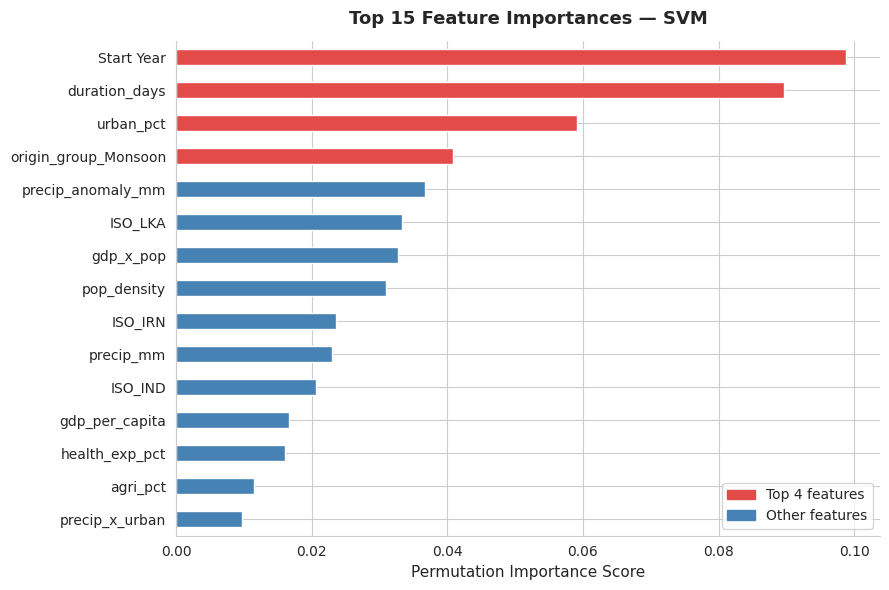

In [ ]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance for SVM
perm_imp = permutation_importance(
    best_svm,
    X_test2_sc,
    y_test2,
    n_repeats=20,
    random_state=42
)

# Convert to series
imp_final = pd.Series(
    perm_imp.importances_mean,
    index=X_test2.columns
)

# Top 15 important features
top15 = imp_final.nlargest(15).sort_values()

# Plot
fig, ax = plt.subplots(figsize=(9,6))

colors = ['#E24B4A' if i >= 11 else 'steelblue'
          for i in range(15)]

top15.plot(
    kind='barh',
    ax=ax,
    color=colors,
    edgecolor='white'
)

ax.set_title(
    'Top 15 Feature Importances — SVM',
    fontsize=13,
    fontweight='bold',
    pad=12
)
ax.set_xlabel('Permutation Importance Score', fontsize=11)
ax.set_ylabel('')

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(color='#E24B4A', label='Top 4 features'),
        Patch(color='steelblue', label='Other features')
    ],
    fontsize=10,
    loc='lower right'
)

sns.despine()
plt.tight_layout()
plt.show()

## Final Model Results

| Model               | Accuracy | F1 Score |
|---------------------|----------|----------|
| Random Forest       | 0.839    | 0.833    |
| SVM                 | 0.828    | 0.828    |
| XGBoost             | 0.828    | 0.815    |
| Logistic Regression | 0.816    | 0.818    |

**Best Model: Random Forest**
- Test Accuracy : 83.9%
- CV Mean       : 78.6% ± 4.6%

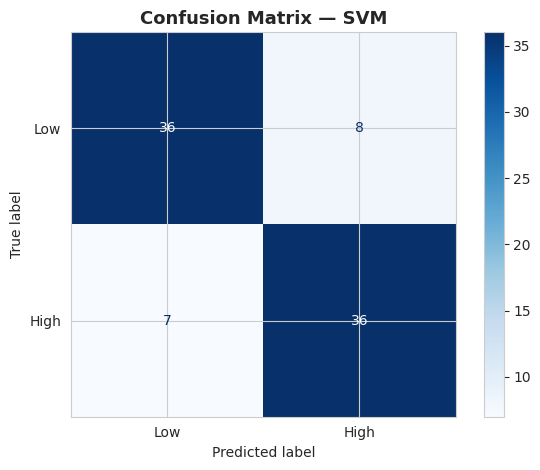

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Fit the best SVM model to the training data
best_svm.fit(X_train2_sc, y_train2)

# Predictions using best SVM model
svm_preds = best_svm.predict(X_test2_sc)

# Confusion matrix
cm = confusion_matrix(y_test2, svm_preds)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low', 'High']
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix — SVM', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Create a realistic flood scenario manually
# Bangladesh, August 2010 — La Nina year, heavy monsoon
sample_input = pd.DataFrame([X_test2.iloc[0]])  # get correct column structure
sample_input[:] = 0  # reset all values

# Fill meaningful values using column names
for col in sample_input.columns:
    if col == 'gdp_per_capita':      sample_input[col] = 750    # poor country
    elif col == 'pop_density':       sample_input[col] = 1100   # very dense
    elif col == 'precip_mm':         sample_input[col] = 380    # heavy rain
    elif col == 'precip_anomaly_mm': sample_input[col] = 200    # far above normal
    elif col == 'oni_value':         sample_input[col] = -1.4   # strong La Nina
    elif col == 'urban_pct':         sample_input[col] = 27     # mostly rural
    elif col == 'duration_days':     sample_input[col] = 14     # 2 week flood
    elif col == 'Start Month':       sample_input[col] = 8      # August
    elif col == 'ISO_BGD':           sample_input[col] = 1      # Bangladesh
    elif col == 'enso_phase_La Nina': sample_input[col] = 1
    elif col == 'Disaster Subtype_Riverine Flood': sample_input[col] = 1

pred = grid_rf.predict(sample_input)
prob = grid_rf.predict_proba(sample_input)
print('--- Flood Scenario ---')
print('Country: Bangladesh | Month: August | Type: Riverine')
print('GDP/capita: $750 | Pop density: 1100/km² | Rainfall: 380mm')
print('ENSO: La Niña (Cool Ocean Phase) (-1.4) | Precip anomaly: +200mm above normal')
print(f'\nPredicted Severity : {"High" if pred[0]==1 else "Low"}')
print(f'Confidence         : Low={prob[0][0]:.2f}  High={prob[0][1]:.2f}')

--- Flood Scenario ---
Country: Bangladesh | Month: August | Type: Riverine
GDP/capita: $750 | Pop density: 1100/km² | Rainfall: 380mm
ENSO: La Niña (Cool Ocean Phase) (-1.4) | Precip anomaly: +200mm above normal

Predicted Severity : High
Confidence         : Low=0.42  High=0.58
